# 03 – Feature Engineering

---

### Vad gör vi i den här notebooken?

Feature engineering är processen där vi skapar nya variabler från rådata som ML-modellerna sedan använder för att lära sig identifiera bull och bear marknader. Bra features är avgörande för modellernas prestanda.

Vi skapar följande kategorier av features:

| Kategori | Features | Syfte |
|----------|----------|-------|
| **Trend** | MA20, MA50, MA200, pris/MA-ratio | Fångar marknadens riktning |
| **Momentum** | RSI, MACD, laggade avkastningar | Mäter rörelsens styrka |
| **Volatilitet** | Std20, Std60, Bollinger Bands, ATR | Mäter marknadens oro |
| **Volym** | Volym-MA, relativ volym | Bekräftar prisrörelser |
| **Korrelation** | Rullande korrelation mellan tillgångar | Unikt för vår studie |

**Input:**  `data/sp500_labeled.csv`, `data/bitcoin_labeled.csv`, `data/gold_labeled.csv`  
**Output:** `data/sp500_features.csv`, `data/bitcoin_features.csv`, `data/gold_features.csv`, `data/combined_features.csv`

## 1. Importera bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR    = '../data'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('✓ Bibliotek importerade')

✓ Bibliotek importerade


## 2. Läs in etiketterad data

Vi läser in de etiketterade filerna från `02_labeling.ipynb` som innehåller OHLCV-data, Regime och Return.

In [2]:
assets = {}

files = {
    'SP500':   'sp500_labeled.csv',
    'Bitcoin': 'bitcoin_labeled.csv',
    'Gold':    'gold_labeled.csv',
}

for name, filename in files.items():
    path = os.path.join(DATA_DIR, filename)
    df   = pd.read_csv(path, index_col='Date', parse_dates=True)
    assets[name] = df
    print(f'✓ {name}: {len(df)} rader, kolumner: {list(df.columns)}')

✓ SP500: 3018 rader, kolumner: ['Open', 'High', 'Low', 'Close', 'Volume', 'Regime', 'Return']
✓ Bitcoin: 4124 rader, kolumner: ['Open', 'High', 'Low', 'Close', 'Volume', 'Regime', 'Return']
✓ Gold: 3017 rader, kolumner: ['Open', 'High', 'Low', 'Close', 'Volume', 'Regime', 'Return']


## 3. Trend-features

Trend-features fångar marknadens övergripande riktning över tid.

- **MA20, MA50, MA200** – rullande medelvärden över 20, 50 och 200 dagar. MA200 är det viktigaste långsiktiga trendfiltret – är priset över MA200 är marknaden generellt i bull-trend.
- **Pris/MA-ratio** – visar hur långt priset avvikit från sitt medelvärde. Värden långt över 1.0 kan signalera överköpt marknad.
- **MA-korsningar** – när MA50 korsar MA200 uppåt kallas det *golden cross* (bullish signal) och nedåt *death cross* (bearish signal).

In [3]:
def add_trend_features(df: pd.DataFrame) -> pd.DataFrame:
    close = df['Close']

    # Rullande medelvärden
    for window in [20, 50, 200]:
        ma = close.rolling(window).mean()
        df[f'MA{window}']       = ma
        df[f'Price_MA{window}'] = close / ma  # ratio: 1.0 = pris på MA

    # Golden cross / Death cross (MA50 vs MA200)
    df['Golden_Cross'] = (df['MA50'] > df['MA200']).astype(int)

    # Prisposition relativt 52-veckors high/low
    df['High_52w'] = close.rolling(252).max()
    df['Low_52w']  = close.rolling(252).min()
    df['Price_52w_position'] = (close - df['Low_52w']) / (df['High_52w'] - df['Low_52w'])

    return df

for name in assets:
    assets[name] = add_trend_features(assets[name])
    print(f'✓ {name}: trend-features tillagda')

✓ SP500: trend-features tillagda
✓ Bitcoin: trend-features tillagda
✓ Gold: trend-features tillagda


### Visualisera trend-features för S&P 500, BTC, Gold

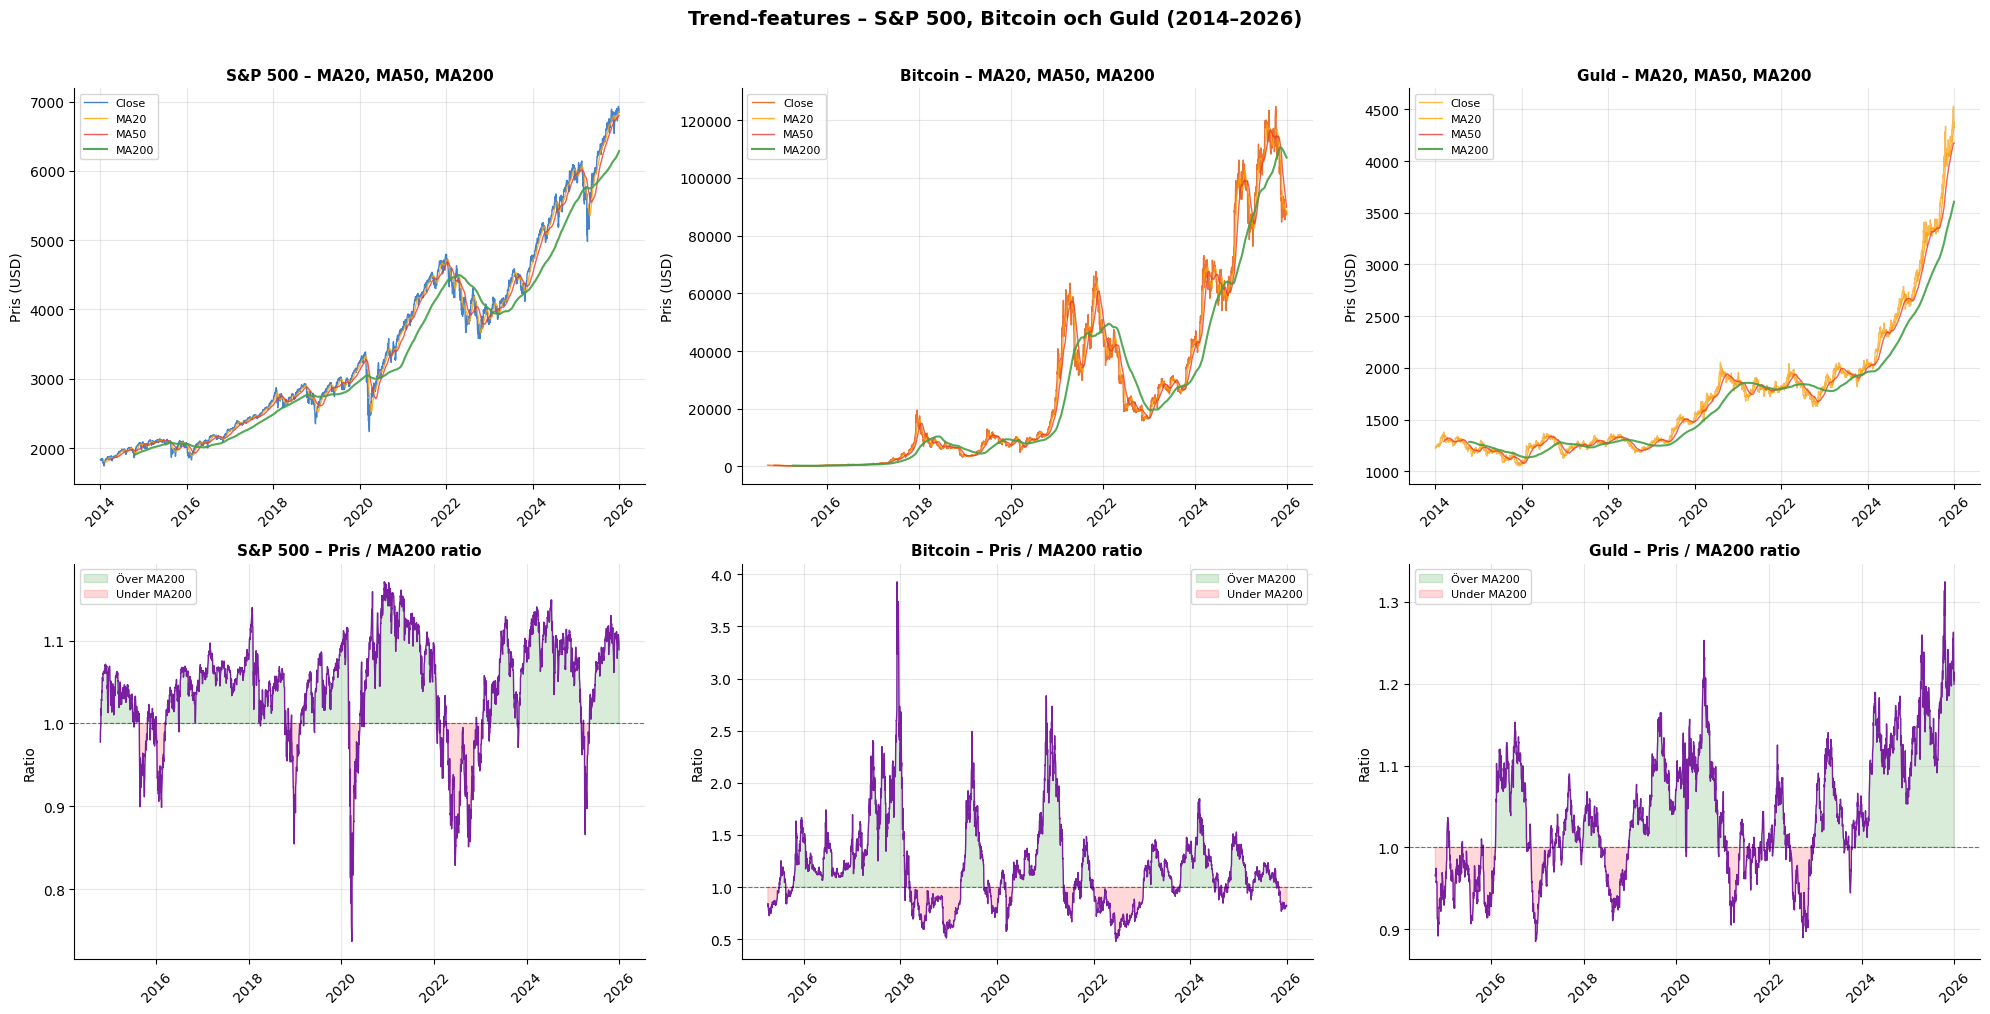

✓ Graf sparad: results/03_trend_features.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

assets_list = [('SP500', '#1565C0', 'S&P 500'), 
               ('Bitcoin', '#E65100', 'Bitcoin'), 
               ('Gold', '#F9A825', 'Guld')]

for col, (name, color, label) in enumerate(assets_list):
    df = assets[name]
    
    # Övre rad: Pris och MA
    ax1 = axes[0, col]
    ax1.plot(df.index, df['Close'], color=color,    linewidth=1,   label='Close', alpha=0.8)
    ax1.plot(df.index, df['MA20'],  color='#FFA000', linewidth=1,   label='MA20',  alpha=0.8)
    ax1.plot(df.index, df['MA50'],  color='#E53935', linewidth=1,   label='MA50',  alpha=0.8)
    ax1.plot(df.index, df['MA200'], color='#43A047', linewidth=1.5, label='MA200', alpha=0.9)
    ax1.set_title(f'{label} – MA20, MA50, MA200', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Pris (USD)')
    ax1.legend(fontsize=8)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax1.xaxis.set_major_locator(mdates.YearLocator(2))
    ax1.tick_params(axis='x', rotation=45)

    # Nedre rad: Price/MA200 ratio
    ax2 = axes[1, col]
    ax2.plot(df.index, df['Price_MA200'], color='#7B1FA2', linewidth=1)
    ax2.axhline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax2.fill_between(df.index, 1.0, df['Price_MA200'],
                     where=(df['Price_MA200'] > 1), alpha=0.15, color='green', label='Över MA200')
    ax2.fill_between(df.index, 1.0, df['Price_MA200'],
                     where=(df['Price_MA200'] < 1), alpha=0.15, color='red', label='Under MA200')
    ax2.set_title(f'{label} – Pris / MA200 ratio', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Ratio')
    ax2.legend(fontsize=8)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax2.xaxis.set_major_locator(mdates.YearLocator(2))
    ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Trend-features – S&P 500, Bitcoin och Guld (2014–2026)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_trend_features.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/03_trend_features.png')

### Visualisering – Rullande medelvärden och Price/MA200-ratio

**Övre raden** visar stängningspriset tillsammans med MA20, MA50 och MA200. MA200 är det viktigaste långsiktiga trendfiltret – priset över MA200 signalerar bull-trend, under signalerar bear-trend.

**Nedre raden** visar Price/MA200-ratio – hur långt priset avvikit från sin långsiktiga trend:
- **Ratio = 1.10** → priset är 10% **över** MA200 (bull-signal)
- **Ratio = 0.90** → priset är 10% **under** MA200 (bear-signal)
- **Ratio = 1.50** → priset är 50% **över** MA200 (kraftig bull)

**Vad vi ser:**
- **S&P 500** – ratio rör sig nära 1.0 (±15%), med tydliga dip under COVID 2020 och 2022
- **Bitcoin** – extremt volatil, når upp till 4.0 under bull markets och under 0.5 under bear markets
- **Guld** – stabil och rör sig lateralt kring 1.0 med mindre avvikelser

Detta visar att samma feature beter sig fundamentalt annorlunda mellan tillgångarna.

## 4. Momentum-features

Momentum-features mäter styrkan och hastigheten i prisrörelser.

- **RSI (Relative Strength Index)** – oscillerar mellan 0 och 100. Värden över 70 = överköpt (potentiell topp), under 30 = översåld (potentiell botten).
- **MACD** – skillnaden mellan MA12 och MA26. När MACD korsar signallinjen uppåt = köpsignal, nedåt = säljsignal.
- **Laggade avkastningar** – vad hände dag t-1, t-2, t-5? Ger modellen historisk kontext utan att det räknas som data leakage.

In [5]:
def compute_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

def add_momentum_features(df: pd.DataFrame) -> pd.DataFrame:
    close  = df['Close']
    ret    = df['Return']

    # RSI
    df['RSI14'] = compute_rsi(close, 14)
    df['RSI7']  = compute_rsi(close, 7)

    # MACD
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df['MACD']        = ema12 - ema26
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_hist']   = df['MACD'] - df['MACD_signal']

    # Laggade avkastningar
    for lag in [1, 2, 3, 5, 10]:
        df[f'Return_lag{lag}'] = ret.shift(lag)

    # Kumulativ avkastning senaste 5, 10, 20 dagarna
    for window in [5, 10, 20]:
        df[f'Cum_return_{window}d'] = (1 + ret).rolling(window).apply(np.prod, raw=True) - 1

    return df

for name in assets:
    assets[name] = add_momentum_features(assets[name])
    print(f'✓ {name}: momentum-features tillagda')

✓ SP500: momentum-features tillagda
✓ Bitcoin: momentum-features tillagda
✓ Gold: momentum-features tillagda


### Visualisera RSI och MACD för S&P 500, BTC, Gold

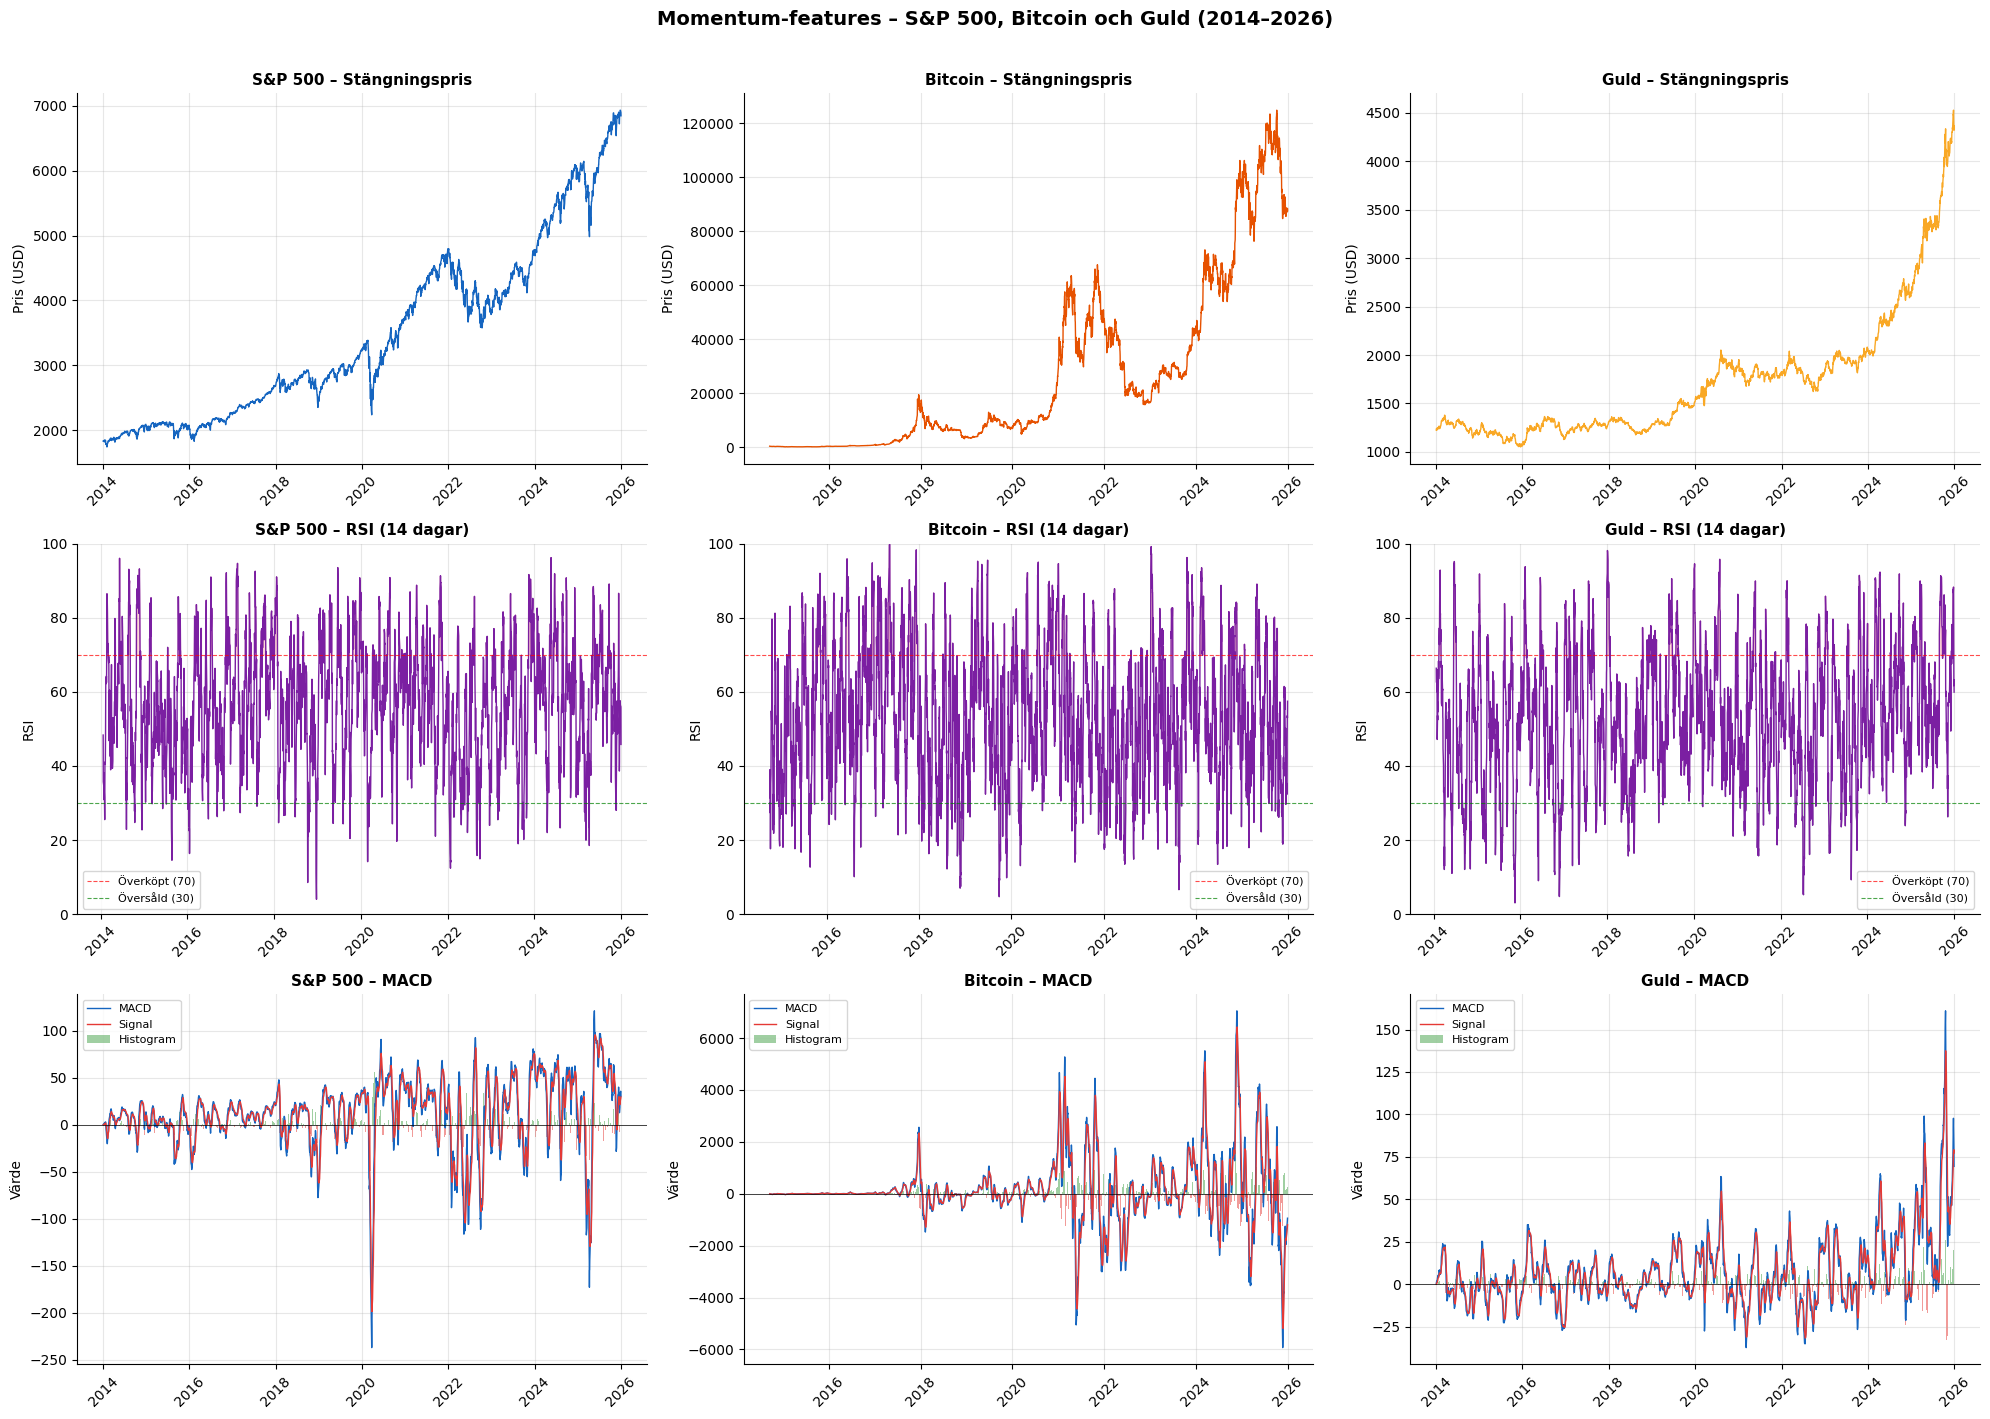

✓ Graf sparad: results/03_momentum_features.png


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14), sharex=False)

assets_list = [('SP500', '#1565C0', 'S&P 500'),
               ('Bitcoin', '#E65100', 'Bitcoin'),
               ('Gold', '#F9A825', 'Guld')]

for col, (name, color, label) in enumerate(assets_list):
    df = assets[name]

    # Övre rad: Pris
    axes[0, col].plot(df.index, df['Close'], color=color, linewidth=1)
    axes[0, col].set_title(f'{label} – Stängningspris', fontsize=11, fontweight='bold')
    axes[0, col].set_ylabel('Pris (USD)')
    axes[0, col].spines['top'].set_visible(False)
    axes[0, col].spines['right'].set_visible(False)
    axes[0, col].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[0, col].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[0, col].tick_params(axis='x', rotation=45)

    # Mellersta rad: RSI
    axes[1, col].plot(df.index, df['RSI14'], color='#7B1FA2', linewidth=1)
    axes[1, col].axhline(70, color='red',   linewidth=0.8, linestyle='--', alpha=0.7, label='Överköpt (70)')
    axes[1, col].axhline(30, color='green', linewidth=0.8, linestyle='--', alpha=0.7, label='Översåld (30)')
    axes[1, col].fill_between(df.index, 70, df['RSI14'], where=(df['RSI14'] > 70), alpha=0.15, color='red')
    axes[1, col].fill_between(df.index, 30, df['RSI14'], where=(df['RSI14'] < 30), alpha=0.15, color='green')
    axes[1, col].set_title(f'{label} – RSI (14 dagar)', fontsize=11, fontweight='bold')
    axes[1, col].set_ylabel('RSI')
    axes[1, col].set_ylim(0, 100)
    axes[1, col].legend(fontsize=8)
    axes[1, col].spines['top'].set_visible(False)
    axes[1, col].spines['right'].set_visible(False)
    axes[1, col].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[1, col].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[1, col].tick_params(axis='x', rotation=45)

    # Nedre rad: MACD
    axes[2, col].plot(df.index, df['MACD'],        color='#1565C0', linewidth=1,   label='MACD')
    axes[2, col].plot(df.index, df['MACD_signal'], color='#E53935', linewidth=1,   label='Signal')
    axes[2, col].bar(df.index,  df['MACD_hist'],   color=df['MACD_hist'].apply(
        lambda x: '#43A047' if x >= 0 else '#E53935'), alpha=0.5, width=1, label='Histogram')
    axes[2, col].axhline(0, color='black', linewidth=0.5)
    axes[2, col].set_title(f'{label} – MACD', fontsize=11, fontweight='bold')
    axes[2, col].set_ylabel('Värde')
    axes[2, col].legend(fontsize=8)
    axes[2, col].spines['top'].set_visible(False)
    axes[2, col].spines['right'].set_visible(False)
    axes[2, col].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[2, col].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[2, col].tick_params(axis='x', rotation=45)

plt.suptitle('Momentum-features – S&P 500, Bitcoin och Guld (2014–2026)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_momentum_features.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/03_momentum_features.png')

### Visualisering – RSI och MACD

**RSI (Relative Strength Index)** oscillerar mellan 0 och 100 och mäter om en tillgång är överköpt eller översåld:
- **RSI > 70 (rött)** → överköpt, priset har stigit för snabbt – potentiell topp
- **RSI < 30 (grönt)** → översåld, priset har fallit för snabbt – potentiell botten
- **RSI ≈ 50** → neutral marknad utan tydlig trend

**MACD (Moving Average Convergence Divergence)** visar skillnaden mellan EMA12 och EMA26:
- **MACD över signallinjen (blå över röd)** → bullish momentum
- **MACD under signallinjen** → bearish momentum
- **Histogrammet** visar styrkan i divergensen – grönt = positivt, rött = negativt

**Vad vi ser:**
- **S&P 500** – RSI rör sig relativt stabilt kring 50, med tydliga dippar under COVID 2020 och 2022
- **Bitcoin** – RSI är extremt volatil och når ofta >80 under bull-toppar och <20 under bear-bottnar, vilket speglar halverings-cyklerna
- **Guld** – liknar S&P 500 men med lägre amplitud, vilket bekräftar att guld är en stabilare tillgång

MACD-värdena för Bitcoin är i absoluta tal mycket större än för S&P 500 och Guld eftersom prisnivåerna skiljer sig. I modellerna används normaliserade versioner av dessa features.

## 5. Volatilitets-features

Volatilitets-features mäter marknadens osäkerhet och oro.

- **Rullande standardavvikelse** – mäter hur mycket avkastningen varierar. Hög volatilitet är ett klassiskt kännetecken för bear markets.
- **Bollinger Bands** – pris ±2 standardavvikelser från MA20. När priset bryter ut ur banden signalerar det ofta en stark rörelse.
- **ATR (Average True Range)** – mäter det genomsnittliga dagliga prisintervallet (High-Low). Högre ATR = mer osäkerhet.

In [7]:
def add_volatility_features(df: pd.DataFrame) -> pd.DataFrame:
    close = df['Close']
    ret   = df['Return']

    # Rullande volatilitet (standardavvikelse på avkastning)
    for window in [10, 20, 60]:
        df[f'Vol_{window}d'] = ret.rolling(window).std()

    # Bollinger Bands (baserade på MA20)
    ma20  = close.rolling(20).mean()
    std20 = close.rolling(20).std()
    df['BB_upper'] = ma20 + 2 * std20
    df['BB_lower'] = ma20 - 2 * std20
    df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / ma20  # normaliserad bredd
    df['BB_position'] = (close - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'])  # 0-1

    # ATR (Average True Range)
    high_low   = df['High'] - df['Low']
    high_close = (df['High'] - close.shift(1)).abs()
    low_close  = (df['Low']  - close.shift(1)).abs()
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df['ATR14'] = true_range.rolling(14).mean()
    df['ATR14_pct'] = df['ATR14'] / close  # normaliserad mot pris

    # Volatilitetskvot: kortsiktig vs långsiktig
    df['Vol_ratio'] = df['Vol_10d'] / df['Vol_60d']

    return df

for name in assets:
    assets[name] = add_volatility_features(assets[name])
    print(f'✓ {name}: volatilitets-features tillagda')

✓ SP500: volatilitets-features tillagda
✓ Bitcoin: volatilitets-features tillagda
✓ Gold: volatilitets-features tillagda


### Visualisera volatilitet och Bollinger Bands för S&P 500, BTC, Gold

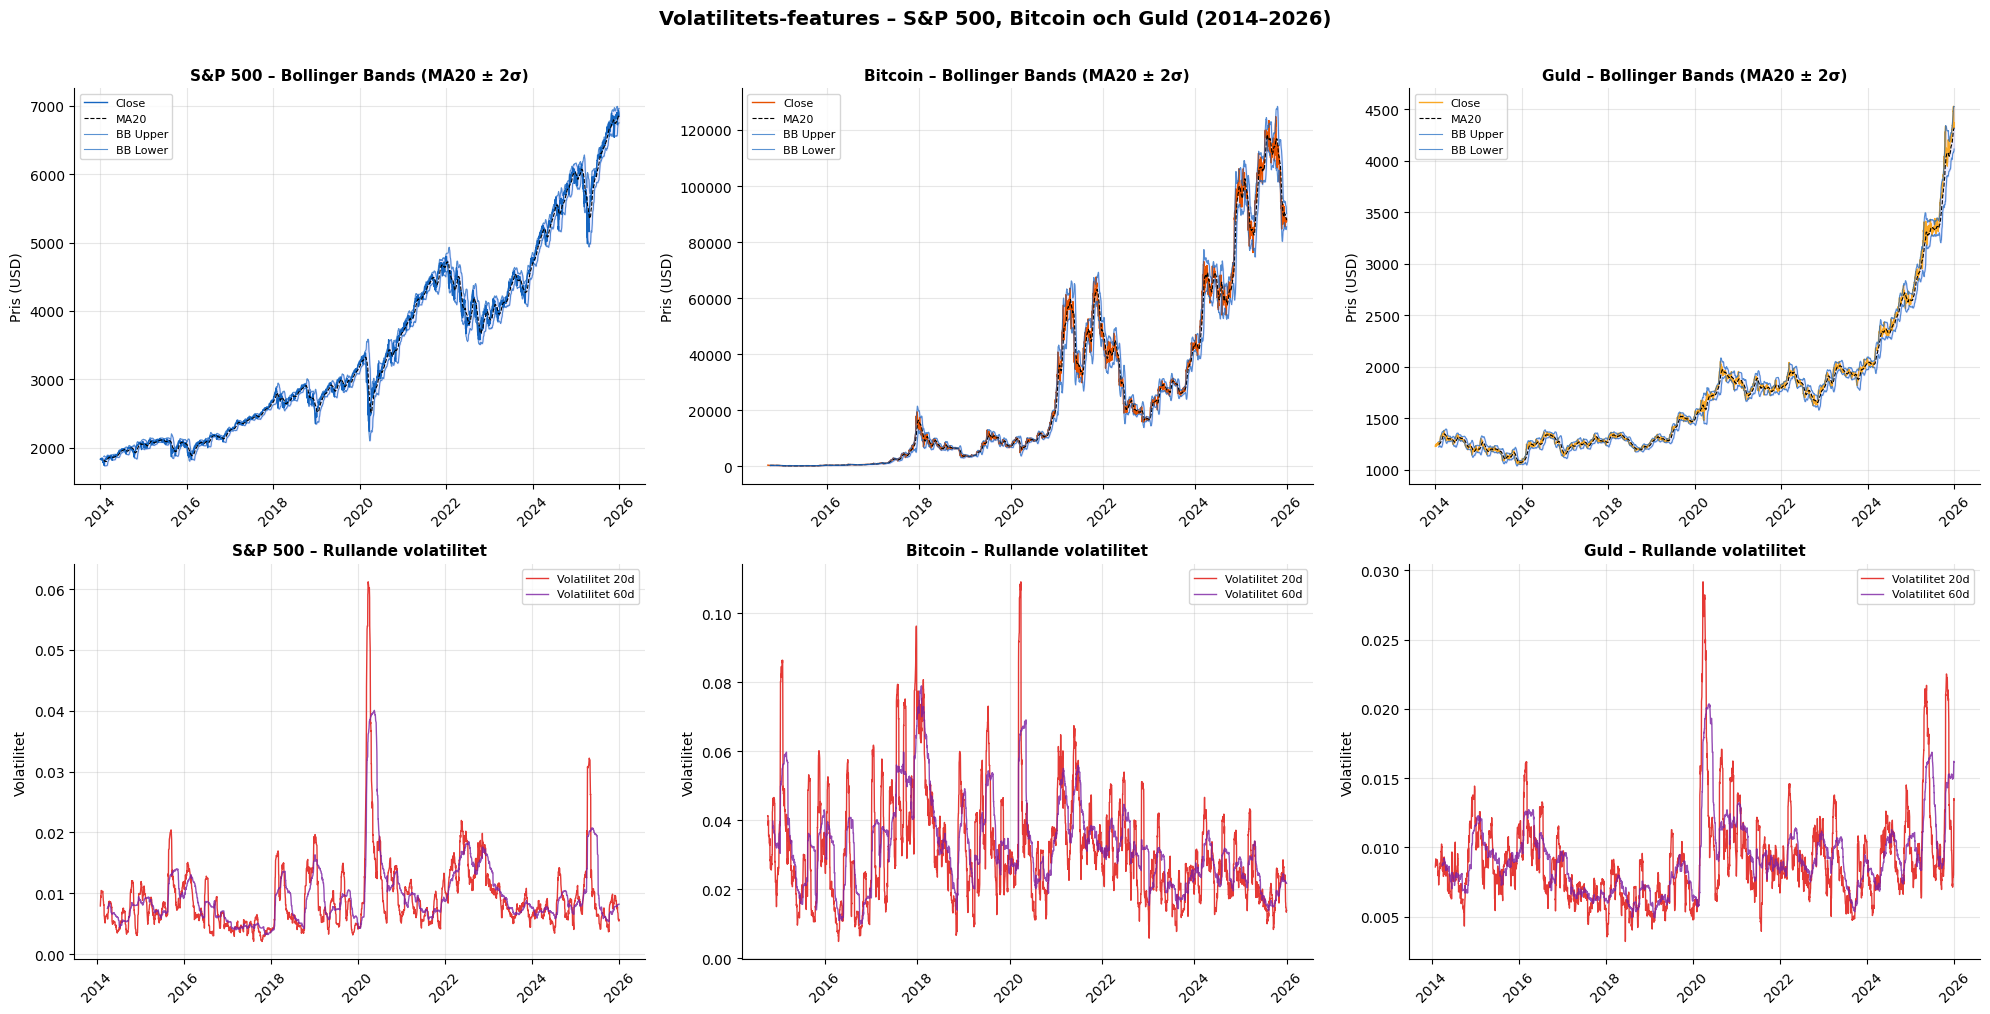

✓ Graf sparad: results/03_volatility_features.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

assets_list = [('SP500', '#1565C0', 'S&P 500'),
               ('Bitcoin', '#E65100', 'Bitcoin'),
               ('Gold', '#F9A825', 'Guld')]

for col, (name, color, label) in enumerate(assets_list):
    df = assets[name]

    # Övre rad: Bollinger Bands
    axes[0, col].plot(df.index, df['Close'],    color=color,    linewidth=1,   label='Close')
    axes[0, col].plot(df.index, df['MA20'],     color='black',  linewidth=0.8, label='MA20', linestyle='--')
    axes[0, col].plot(df.index, df['BB_upper'], color='#1565C0', linewidth=0.8, label='BB Upper', alpha=0.7)
    axes[0, col].plot(df.index, df['BB_lower'], color='#1565C0', linewidth=0.8, label='BB Lower', alpha=0.7)
    axes[0, col].fill_between(df.index, df['BB_lower'], df['BB_upper'], alpha=0.08, color='blue')
    axes[0, col].set_title(f'{label} – Bollinger Bands (MA20 ± 2σ)', fontsize=11, fontweight='bold')
    axes[0, col].set_ylabel('Pris (USD)')
    axes[0, col].legend(fontsize=8)
    axes[0, col].spines['top'].set_visible(False)
    axes[0, col].spines['right'].set_visible(False)
    axes[0, col].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[0, col].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[0, col].tick_params(axis='x', rotation=45)

    # Nedre rad: Rullande volatilitet
    axes[1, col].plot(df.index, df['Vol_20d'], color='#E53935', linewidth=1, label='Volatilitet 20d')
    axes[1, col].plot(df.index, df['Vol_60d'], color='#7B1FA2', linewidth=1, label='Volatilitet 60d', alpha=0.8)
    axes[1, col].set_title(f'{label} – Rullande volatilitet', fontsize=11, fontweight='bold')
    axes[1, col].set_ylabel('Volatilitet')
    axes[1, col].legend(fontsize=8)
    axes[1, col].spines['top'].set_visible(False)
    axes[1, col].spines['right'].set_visible(False)
    axes[1, col].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[1, col].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[1, col].tick_params(axis='x', rotation=45)

plt.suptitle('Volatilitets-features – S&P 500, Bitcoin och Guld (2014–2026)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_volatility_features.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/03_volatility_features.png')

### Visualisering – Bollinger Bands och Rullande volatilitet

**Bollinger Bands (övre raden)** visar MA20 ± 2 standardavvikelser:
- **Smala band** → låg volatilitet, lugn marknad
- **Breda band** → hög volatilitet, orolig marknad
- När priset **bryter ut ur banden** signalerar det ofta en stark rörelse

**Rullande volatilitet (nedre raden)** visar standardavvikelsen på daglig avkastning över 20 och 60 dagar:
- Höga toppar sammanfaller med kända kriser – COVID 2020 syns tydligt i alla tre tillgångarna
- Vol_20d (röd) reagerar snabbt på marknadsrörelser
- Vol_60d (lila) är jämnare och fångar den strukturella volatilitetsnivån

**Jämförelse mellan tillgångarna:**
- **S&P 500** – låg volatilitet (~1%) med en kraftig topp under COVID 2020 (~6%)
- **Bitcoin** – strukturellt hög volatilitet (~3–8%), inga tydliga toppar utan snarare konstant brus
- **Guld** – lägst volatilitet av de tre (~0.5–2%), med en tydlig topp under COVID 2020

## 6. Volym-features

Volym-features bekräftar prisrörelser – en uppgång med hög volym är starkare än en uppgång med låg volym.

- **Volym-MA** – rullande medelvärde på volymen
- **Relativ volym** – dagens volym relativt genomsnittet. Värden över 2.0 indikerar ovanligt hög aktivitet.
- **On-Balance Volume (OBV)** – ackumulerar volymen beroende på om priset steg eller föll. En stigande OBV bekräftar en upptrend.

In [9]:
def add_volume_features(df: pd.DataFrame) -> pd.DataFrame:
    volume = df['Volume']
    close  = df['Close']

    # Rullande volym-medelvärden
    df['Vol_MA20'] = volume.rolling(20).mean()
    df['Vol_MA50'] = volume.rolling(50).mean()

    # Relativ volym (dagens volym vs 20-dagars snitt)
    df['Rel_Volume'] = volume / df['Vol_MA20']

    # On-Balance Volume (OBV)
    obv = [0]
    for i in range(1, len(df)):
        if close.iloc[i] > close.iloc[i-1]:
            obv.append(obv[-1] + volume.iloc[i])
        elif close.iloc[i] < close.iloc[i-1]:
            obv.append(obv[-1] - volume.iloc[i])
        else:
            obv.append(obv[-1])
    df['OBV'] = obv
    df['OBV_MA20'] = pd.Series(obv, index=df.index).rolling(20).mean()

    return df

for name in assets:
    assets[name] = add_volume_features(assets[name])
    print(f'✓ {name}: volym-features tillagda')

✓ SP500: volym-features tillagda
✓ Bitcoin: volym-features tillagda
✓ Gold: volym-features tillagda


### Visualisera volym-features för S&P 500, BTC, Gold

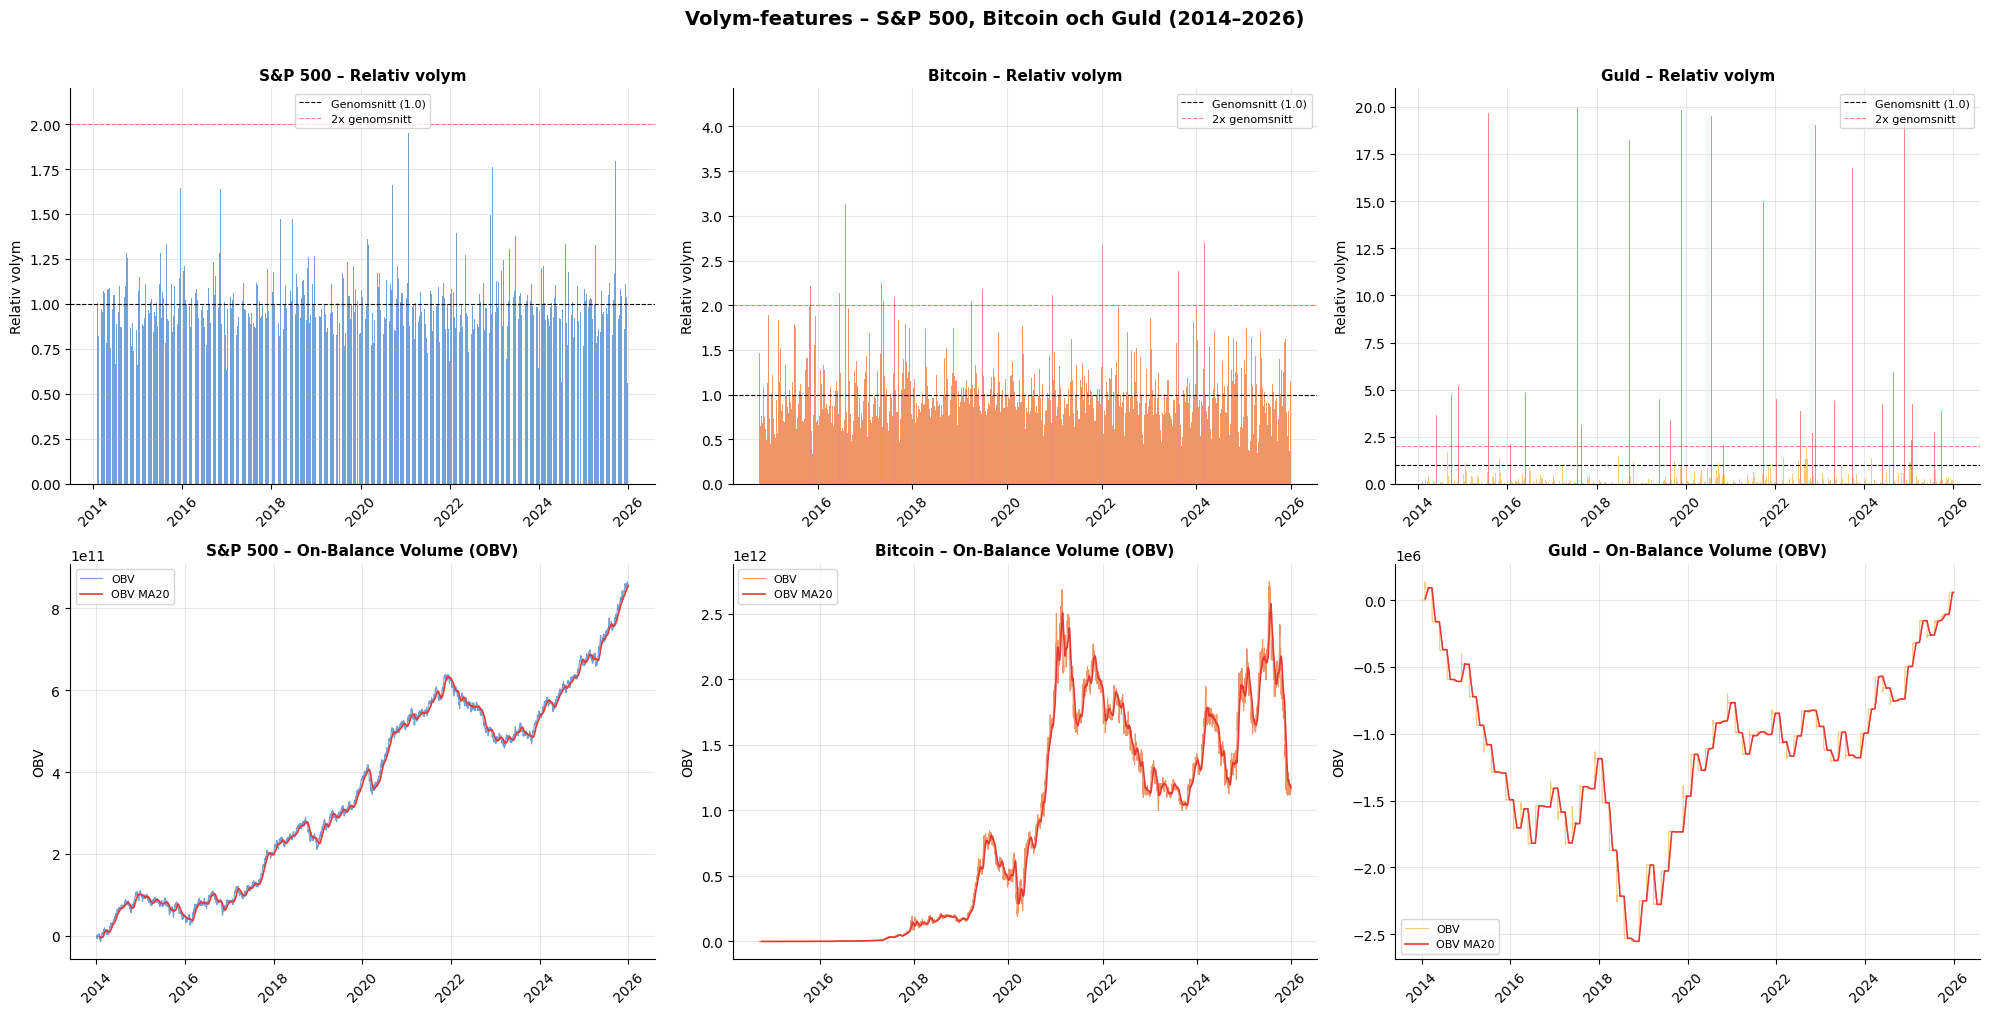

✓ Graf sparad: results/03_volume_features.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

assets_list = [('SP500', '#1565C0', 'S&P 500'),
               ('Bitcoin', '#E65100', 'Bitcoin'),
               ('Gold', '#F9A825', 'Guld')]

for col, (name, color, label) in enumerate(assets_list):
    df = assets[name]

    # Övre rad: Relativ volym
    axes[0, col].bar(df.index, df['Rel_Volume'],
                     color=df['Rel_Volume'].apply(lambda x: '#E53935' if x > 2 else color),
                     alpha=0.6, width=1)
    axes[0, col].axhline(1.0, color='black', linewidth=0.8, linestyle='--', label='Genomsnitt (1.0)')
    axes[0, col].axhline(2.0, color='red',   linewidth=0.8, linestyle='--', alpha=0.5, label='2x genomsnitt')
    axes[0, col].set_title(f'{label} – Relativ volym', fontsize=11, fontweight='bold')
    axes[0, col].set_ylabel('Relativ volym')
    axes[0, col].legend(fontsize=8)
    axes[0, col].spines['top'].set_visible(False)
    axes[0, col].spines['right'].set_visible(False)
    axes[0, col].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[0, col].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[0, col].tick_params(axis='x', rotation=45)

    # Nedre rad: OBV
    axes[1, col].plot(df.index, df['OBV'],      color=color,    linewidth=0.8, label='OBV',      alpha=0.6)
    axes[1, col].plot(df.index, df['OBV_MA20'], color='#E53935', linewidth=1.2, label='OBV MA20')
    axes[1, col].set_title(f'{label} – On-Balance Volume (OBV)', fontsize=11, fontweight='bold')
    axes[1, col].set_ylabel('OBV')
    axes[1, col].legend(fontsize=8)
    axes[1, col].spines['top'].set_visible(False)
    axes[1, col].spines['right'].set_visible(False)
    axes[1, col].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[1, col].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[1, col].tick_params(axis='x', rotation=45)

plt.suptitle('Volym-features – S&P 500, Bitcoin och Guld (2014–2026)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_volume_features.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/03_volume_features.png')

### Visualisering – Relativ volym och OBV

**Relativ volym (övre raden)** visar dagens volym relativt 20-dagars genomsnitt:
- **Ratio = 1.0** → normal volym
- **Ratio = 2.0** → dubbel volym, ovanligt hög aktivitet (markerat i rött)
- Höga volymspikar sammanfaller ofta med stora prisrörelser och regimskiften

**On-Balance Volume / OBV (nedre raden)** ackumulerar volymen:
- **Stigande OBV** → mer köpvolym än säljvolym → bekräftar upptrend
- **Fallande OBV** → mer säljvolym → bekräftar nedtrend
- OBV kan vara negativ – det betyder inte att något är fel, bara att säljvolymen dominerat historiskt

**Vad vi ser:**
- **S&P 500** – relativ volym håller sig nära 1.0, OBV stiger stadigt och bekräftar bull-trenden
- **Bitcoin** – högre relativ volatilitet i volymen, OBV visar tydliga bull/bear-cykler med kraftiga ras under 2018 och 2022
- **Guld** – extrem spridning i relativ volym (upp till 20x) pga låg genomsnittsvolym på futures-kontrakt, OBV är negativ men trendade uppåt sedan 2022

## 7. Korrelations-features

Korrelations-features är unika för vår studie och direkt kopplade till **RQ3** – hur förändras sambandet mellan tillgångarna i bull vs bear?

- **Rullande korrelation (60 dagar)** – visar hur starkt S&P 500, Bitcoin och Guld rör sig tillsammans
- Under bear markets tenderar korrelationer att öka (tillgångar faller tillsammans)
- Guld förväntas ha negativ eller låg korrelation med S&P 500 under kriser (safe-haven)

In [22]:
# Hämta avkastningar och säkerställ gemensamt index
returns = pd.DataFrame({
    'SP500':   assets['SP500']['Return'],
    'Bitcoin': assets['Bitcoin']['Return'],
    'Gold':    assets['Gold']['Return'],
}).dropna()

# Rullande korrelation – 60 dagar
CORR_WINDOW = 60

corr_sp500_btc  = returns['SP500'].rolling(CORR_WINDOW).corr(returns['Bitcoin'])
corr_sp500_gold = returns['SP500'].rolling(CORR_WINDOW).corr(returns['Gold'])
corr_btc_gold   = returns['Bitcoin'].rolling(CORR_WINDOW).corr(returns['Gold'])

for name in assets:
    assets[name]['Corr_SP500_BTC']  = corr_sp500_btc
    assets[name]['Corr_SP500_Gold'] = corr_sp500_gold
    assets[name]['Corr_BTC_Gold']   = corr_btc_gold

print(f'✓ Rullande {CORR_WINDOW}-dagarskorrelation beräknad')
print(f'  Period: {returns.index.min().date()} → {returns.index.max().date()}')
print(f'  Antal handelsdagar: {len(returns)}')

✓ Rullande 60-dagarskorrelation beräknad
  Period: 2014-09-18 → 2025-12-31
  Antal handelsdagar: 2836


In [23]:
# Kontrollera att korrelationerna finns
print("Kolumner i SP500:")
corr_cols = [c for c in assets['SP500'].columns if 'Corr' in c]
print(corr_cols)

print("\nSaknade värden:")
for col in corr_cols:
    print(f"  {col}: {assets['SP500'][col].isna().sum()} NaN")

Kolumner i SP500:
['Corr_SP500_BTC', 'Corr_SP500_Gold', 'Corr_BTC_Gold']

Saknade värden:
  Corr_SP500_BTC: 241 NaN
  Corr_SP500_Gold: 241 NaN
  Corr_BTC_Gold: 241 NaN


In [13]:
# Droppa rader där någon tillgång saknar data
returns_clean = returns.dropna()

print(f"Rader efter dropna: {len(returns_clean)}")
print(f"Period: {returns_clean.index.min().date()} → {returns_clean.index.max().date()}")


Rader efter dropna: 2836
Period: 2014-09-18 → 2025-12-31


In [14]:
print("Returns index typ:", returns.index.dtype)
print("SP500 antal rader:", len(returns['SP500'].dropna()))
print("Bitcoin antal rader:", len(returns['Bitcoin'].dropna()))
print("Gold antal rader:", len(returns['Gold'].dropna()))
print("\nReturns head:")
print(returns.head(10))
print("\nReturns tail:")
print(returns.tail(10))


Returns index typ: datetime64[us]
SP500 antal rader: 2836
Bitcoin antal rader: 2836
Gold antal rader: 2836

Returns head:
               SP500   Bitcoin      Gold
Date                                    
2014-09-18  0.004891 -0.071926 -0.007048
2014-09-19 -0.000477 -0.069843 -0.008485
2014-09-22 -0.008013  0.008352  0.001234
2014-09-23 -0.005777  0.083647  0.003452
2014-09-24  0.007832 -0.028881 -0.001966
2014-09-25 -0.016169 -0.027483  0.002134
2014-09-26  0.008576 -0.017370 -0.005814
2014-09-29 -0.002547 -0.004544  0.002800
2014-09-30 -0.002786  0.030567 -0.005749
2014-10-01 -0.013249 -0.008603  0.003387

Returns tail:
               SP500   Bitcoin      Gold
Date                                    
2025-12-17 -0.011592 -0.019355  0.009990
2025-12-18  0.007934 -0.007908 -0.001840
2025-12-19  0.008818  0.030901  0.005047
2025-12-22  0.006436 -0.001486  0.019076
2025-12-23  0.004550 -0.012160  0.008595
2025-12-24  0.003221  0.002265 -0.000491
2025-12-26 -0.000304  0.000764  0.010824
20

In [19]:
# Kontrollera returns_clean
returns_clean = pd.DataFrame({
    'SP500':   assets['SP500']['Return'],
    'Bitcoin': assets['Bitcoin']['Return'],
    'Gold':    assets['Gold']['Return'],
}).dropna()

print(f"Rader: {len(returns_clean)}")
print(f"Period: {returns_clean.index.min().date()} → {returns_clean.index.max().date()}")

# Beräkna korrelationer direkt
corr_sp500_btc  = returns_clean['SP500'].rolling(60).corr(returns_clean['Bitcoin'])
corr_sp500_gold = returns_clean['SP500'].rolling(60).corr(returns_clean['Gold'])
corr_btc_gold   = returns_clean['Bitcoin'].rolling(60).corr(returns_clean['Gold'])

print(f"\nSP500-BTC  NaN: {corr_sp500_btc.isna().sum()}")
print(f"SP500-Gold NaN: {corr_sp500_gold.isna().sum()}")
print(f"BTC-Gold   NaN: {corr_btc_gold.isna().sum()}")

Rader: 2836
Period: 2014-09-18 → 2025-12-31

SP500-BTC  NaN: 59
SP500-Gold NaN: 59
BTC-Gold   NaN: 59


### Visualisera rullande korrelationer

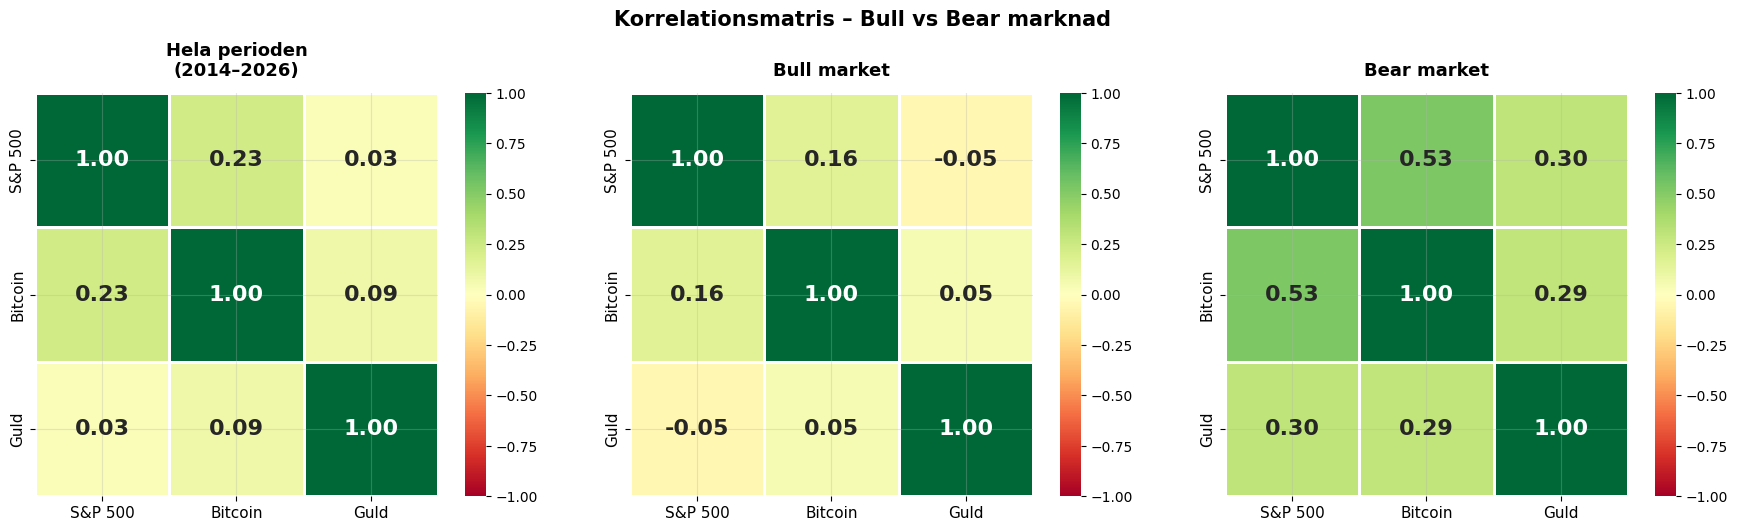

✓ Graf sparad: results/03_correlation_heatmap.png


In [20]:
# Beräkna genomsnittlig korrelation per regim
regimes = {'Bull': 1, 'Bear': 0}
regime  = assets['SP500']['Regime']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ['Hela perioden\n(2014–2026)', 'Bull market', 'Bear market']
masks  = [
    pd.Series(True, index=returns_clean.index),
    regime.reindex(returns_clean.index) == 1,
    regime.reindex(returns_clean.index) == 0,
]

labels = ['S&P 500', 'Bitcoin', 'Guld']

for ax, title, mask in zip(axes, titles, masks):
    data   = returns_clean[mask.fillna(False)]
    matrix = data.corr()
    matrix.index   = labels
    matrix.columns = labels

    sns.heatmap(
        matrix,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        vmin=-1, vmax=1,
        linewidths=2,
        square=True,
        annot_kws={'size': 16, 'weight': 'bold'},
        cbar=True,
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.tick_params(axis='both', labelsize=11)

plt.suptitle('Korrelationsmatris – Bull vs Bear marknad',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/03_correlation_heatmap.png')

### Visualisering – Korrelationsmatris: Hela perioden, Bull och Bear

Heatmapen visar genomsnittlig korrelation mellan tillgångarna uppdelat på hela 
perioden, bull market och bear market. Skalan går från röd (-1.0, perfekt negativ 
korrelation) till grön (1.0, perfekt positiv korrelation).

**Vad vi ser – och det är ett av arbetets viktigaste fynd:**

| Par | Hela perioden | Bull market | Bear market |
|-----|--------------|-------------|-------------|
| S&P 500 vs Bitcoin | 0.23 | 0.16 | **0.53** |
| S&P 500 vs Guld | 0.03 | -0.05 | **0.30** |
| Bitcoin vs Guld | 0.09 | 0.05 | **0.29** |

**Alla tre korrelationer ökar kraftigt under bear markets** – detta är ett klassiskt 
"correlation breakdown"-fenomen där tillgångar som normalt rör sig oberoende av 
varandra plötsligt faller tillsammans under kriser.

**Implikationer:**
- **Bitcoin** är inte en safe-haven under bear markets – korrelationen med S&P 500 
  tredubblas från 0.16 till 0.53
- **Guld** beter sig mer som safe-haven – korrelationen med S&P 500 är negativ 
  (-0.05) under bull markets men stiger under bear markets
- Detta motiverar direkt vår studie – marknadsregimen påverkar hur tillgångarna 
  förhåller sig till varandra

## 8. Sammanställ och spara features

Nu sammanställer vi alla features och sparar dem. Vi tar bort rader med NaN som uppstår från rullande fönster (ex. MA200 kräver 200 rader innan den kan beräknas).

In [25]:
cols_to_drop = [
    'Corr_SP500_BTC_30d',
    'Corr_SP500_Gold_30d',
    'Corr_BTC_Gold_30d',
    'Corr_SP500_BTC_60d',
    'Corr_SP500_Gold_60d',
    'Corr_BTC_Gold_60d',
    'Corr_SP500_BTC_90d',
    'Corr_SP500_Gold_90d',
    'Corr_BTC_Gold_90d',
    'MA20', 'MA50', 'MA200',
    'BB_upper', 'BB_lower',
    'High_52w', 'Low_52w',
    'Vol_MA20', 'Vol_MA50',
    'OBV',
    'ATR14',
]

for name in assets:
    existing = [c for c in cols_to_drop if c in assets[name].columns]
    assets[name] = assets[name].drop(columns=existing)

print('── Slutliga features per tillgång ─────────────────')
for name, df in assets.items():
    feature_cols = [c for c in df.columns if c not in
                    ['Open', 'High', 'Low', 'Close', 'Volume', 'Regime', 'Return']]
    print(f'{name}: {len(feature_cols)} features')
    print(f'  {feature_cols}\n')

── Slutliga features per tillgång ─────────────────
SP500: 30 features
  ['Price_MA20', 'Price_MA50', 'Price_MA200', 'Golden_Cross', 'Price_52w_position', 'RSI14', 'RSI7', 'MACD', 'MACD_signal', 'MACD_hist', 'Return_lag1', 'Return_lag2', 'Return_lag3', 'Return_lag5', 'Return_lag10', 'Cum_return_5d', 'Cum_return_10d', 'Cum_return_20d', 'Vol_10d', 'Vol_20d', 'Vol_60d', 'BB_width', 'BB_position', 'ATR14_pct', 'Vol_ratio', 'Rel_Volume', 'OBV_MA20', 'Corr_SP500_BTC', 'Corr_SP500_Gold', 'Corr_BTC_Gold']

Bitcoin: 30 features
  ['Price_MA20', 'Price_MA50', 'Price_MA200', 'Golden_Cross', 'Price_52w_position', 'RSI14', 'RSI7', 'MACD', 'MACD_signal', 'MACD_hist', 'Return_lag1', 'Return_lag2', 'Return_lag3', 'Return_lag5', 'Return_lag10', 'Cum_return_5d', 'Cum_return_10d', 'Cum_return_20d', 'Vol_10d', 'Vol_20d', 'Vol_60d', 'BB_width', 'BB_position', 'ATR14_pct', 'Vol_ratio', 'Rel_Volume', 'OBV_MA20', 'Corr_SP500_BTC', 'Corr_SP500_Gold', 'Corr_BTC_Gold']

Gold: 30 features
  ['Price_MA20', 'Price_

In [26]:
# Spara separata feature-filer per tillgång
for name, df in assets.items():
    df_clean = df.dropna()
    filename = f'{name.lower()}_features.csv'
    filepath = os.path.join(DATA_DIR, filename)
    df_clean.to_csv(filepath)
    print(f'✓ Sparad: data/{filename}  ({len(df_clean)} rader efter dropna)')

# Spara kombinerad fil med alla tre tillgångar
dfs = []
for name, df in assets.items():
    df_prefixed = df.copy()
    # Behåll originalnamnens kolumner utan prefix för OHLCV och regime
    rename_cols = {c: f'{name}_{c}' for c in df.columns
                   if c not in ['Regime']}
    df_prefixed = df_prefixed.rename(columns=rename_cols)
    dfs.append(df_prefixed)

combined = pd.concat(dfs, axis=1).dropna()
combined.to_csv(os.path.join(DATA_DIR, 'combined_features.csv'))
print(f'\n✓ Kombinerad fil: data/combined_features.csv')
print(f'  {combined.shape[0]} rader × {combined.shape[1]} kolumner')

✓ Sparad: data/sp500_features.csv  (2764 rader efter dropna)
✓ Sparad: data/bitcoin_features.csv  (2665 rader efter dropna)
✓ Sparad: data/gold_features.csv  (2764 rader efter dropna)

✓ Kombinerad fil: data/combined_features.csv
  2665 rader × 111 kolumner


## 10. Sammanfattning

Vi har skapat följande features per tillgång:

| Kategori | Features | Antal |
|----------|----------|-------|
| Trend | Price_MA20/50/200, Golden_Cross, Price_52w_position | 5 |
| Momentum | RSI7, RSI14, MACD, MACD_signal, MACD_hist, Return_lag1/2/3/5/10, Cum_return_5/10/20d | 13 |
| Volatilitet | Vol_10/20/60d, BB_width, BB_position, ATR14_pct, Vol_ratio | 7 |
| Volym | Rel_Volume, OBV_MA20 | 2 |
| Korrelation | Corr_SP500_BTC_60d, Corr_SP500_Gold_60d, Corr_BTC_Gold_60d | 3 |
| **Totalt** | | **30 features per tillgång** |

**Viktiga observationer:**
- Råa MA-värden och BB-värden togs bort – normaliserade ratio-versioner används istället
- Korrelationerna beräknades på gemensamt index (vardagar där alla tre tillgångar har data)
- Korrelationsmatrisen visar att alla samband ökar under bear markets – starkast för S&P 500 vs Bitcoin (0.16 → 0.53)
- NaN-rader droppades pga rullande fönster – MA200 kräver 200 dagar innan den kan beräknas
- Sparade filer: `sp500_features.csv`, `bitcoin_features.csv`, `gold_features.csv`, `combined_features.csv`

**Nästa steg:** `04_hmm.ipynb` – Hidden Markov Model för osupervised regimdetektering.